#  Project Stage III — Machine Learning Models

## In this stage, you will test your hypotheses statistically and explore how machine learning models can capture relationships in your cleaned dataset. This task builds the bridge between statistics and predictive modeling.

### Task 1- Hypothesis Verification (30 points)

Revisit all the Hypothsis questions proposed in Stage II.  

a. Write the hypotheses explicitly: 

    Null (H₀): no difference or no relationship.

    Alternative (H₁): difference or relationship exists. 

### Budget vs. Revenue

Do movies with higher production budgets generate higher revenues compared to lower-budget films?

- Null Hypothesis (H₀): Movies with higher production budgets do not generate higher revenues compared to lower-budget films.

- Alternative Hypothesis (H₁): Movies with higher production budgets generate higher revenues compared to lower-budget films.

### Audience Engagement vs. Revenue

Do movies with higher popularity scores achieve greater revenues than movies with lower popularity?

- Null Hypothesis (H₀): Movies with higher popularity scores do not achieve greater revenues than movies with lower popularity scores.

- Alternative Hypothesis (H₁): Movies with higher popularity scores achieve greater revenues than movies with lower popularity scores.

### Genre vs. Revenue

Do certain genres (e.g., Action, Adventure, or Animation) generate higher revenues on average compared to other genres (e.g., Drama or Documentary)?

- Null Hypothesis (H₀): There is no difference in average revenue between movie genres.

- Alternative Hypothesis (H₁): Certain movie genres generate higher average revenues than other genres.

b. Then choose and justify an approporiate test:
    
    t-test / ANOVA – compare means across groups.

    Chi-square test – association between two categorical variables.

    Correlation test (Pearson/Spearman) – relationship between continuous or ordinal variables.

    Regression coefficient test – check if a variable significantly predicts another.

### Budget vs. Revenue

Recommended Test: Pearson Correlation and Regression coefficient test

Justification: Both budget and revenue are continuous. Correlation will show if they move together, while regression will test predictive power.

### Audience Engagement vs. Revenue

Recommended Test: Pearson Correlation and Regression coefficient test

Justification: Both variables are continuous. Correlation reveals association; regression tests prediction.

### Genre vs. Revenue

Recommended Test: ANOVA (Analysis of Variance)

Justification: Genre is categorical with multiple levels (e.g., Action, Drama, Documentary), and revenue is continuous. ANOVA is ideal for comparing means across these groups.

c. Report the test statistic, p-value and compare them with significance level ($\alpha = 0.05$), interpret your results clearly: Reject $H_0$ or fail to reject $H_0$ and explain what it means in the context of your dataset.

In [1]:
# imports
import pandas as pd
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy.stats import f_oneway
import statsmodels.formula.api as smf
df = pd.read_csv("data/newdata.csv")

### Budget vs. Revenue (Pearson Correlation and Regression Coefficient Test)

In [2]:
# a very small percentage of budget and revenue values are nan, and we need to remove them for pearsonr to work
df_h1 = df.dropna(subset=["budget", "revenue"])

X = df_h1["budget"]         
y = df_h1["revenue"]       
# adds the intercept term
X = sm.add_constant(X)       
model = sm.OLS(y, X).fit()

correlation, p_value = pearsonr(df_h1["budget"], df_h1["revenue"])
intercept = model.params["const"]
slope = model.params["budget"]
t_statistic = model.tvalues["budget"]

print(f"Test statistic (t-value): {t_statistic:.2f}")
print(f"P-value: {p_value:.2f}")
print(f"Correlation: {correlation*100:.2f}%")
print(f"Linear equation: y = {intercept:.2f} {slope:+.2f} x")


Test statistic (t-value): 56.53
P-value: 0.00
Correlation: 70.54%
Linear equation: y = 902540.95 +2.96 x


Compared with a signifigance level of 0.05, our p-value of 0.00 is smaller. This means that we will reject the null hypothesis, and assume the alternative hypothesis (H₁) is true. Our alternative hyothesis states that there is a relationship between the variables. Here we  assume it is the linear equation shown above. This seems like a pretty good fit as the variables have over 70% linear correlation. In the context of our dataset, this means that budget and revenue are linearly related, and we can predict revenue by calculating 902540.95 +2.96 * (budget).

### Audience Engagement vs. Revenue (Pearson Correlation and Regression Coefficient Test)

In [3]:
# a very small percentage of revenue values are nan, and we need to remove them for pearsonr to work
df_h2 = df.dropna(subset=["revenue"])

X = df_h2["popularity"]         
y = df_h2["revenue"]       
# adds the intercept term
X = sm.add_constant(X)       
model = sm.OLS(y, X).fit()

correlation, p_value = pearsonr(df_h2["popularity"], df_h2["revenue"])
intercept = model.params["const"]
slope = model.params["popularity"]
t_statistic = model.tvalues["popularity"]

print(f"Test statistic (t-value): {t_statistic:.2f}")
print(f"P-value: {p_value*100:.2f}")
print(f"Correlation: {correlation*100:.2f}%")
print(f"Linear equation: y = {intercept:.2f} {slope:+.2f} x")


Test statistic (t-value): 44.25
P-value: 0.00
Correlation: 60.60%
Linear equation: y = 28820560.93 +3121346.65 x


Compared with a signifigance level of 0.05, our p-value of 0.00 is smaller. This means that we will reject the null hypothesis, and assume the alternative hypothesis (H₁) is true. Our alternative hyothesis states that there is a relationship between the variables. Here we  assume it is the linear equation shown above. This seems like an alright fit as the variables have over 60% linear correlation. In the context of our dataset, this means that popularity and revenue are linearly related, and we can predict revenue by calculating 28820560.93 +3121346.65 * (popularity)

### Genre vs. Revenue (ANOVA / Analysis of Variance)

In [4]:
import pandas as pd
from scipy.stats import f_oneway
import statsmodels.api as sm
import statsmodels.formula.api as smf

# a very small percentage of genres and revenue values are nan, and we need to remove them for ols to work
df_h3 = df.dropna(subset=["genres", "revenue"])

# Separate revenue values by genre group
groups = [
    group["revenue"].values
    for _, group in df_h3.groupby("genres")
]

f_stat, p_value = f_oneway(*groups)
model = smf.ols('revenue ~ C(genres)', data=df_h3).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.4f}")
print(anova_table)


F-statistic: 2.7137
P-value:     0.0000
                 sum_sq      df         F        PR(>F)
C(genres)  5.859524e+19   951.0  2.713684  5.035287e-85
Residual   5.501434e+19  2423.0       NaN           NaN


Compared with our significance level of 0.05, our p-value of 0.0000 is smaller. This means that we will reject the null hypothesis, and assume the alternative hypothesis (H₁) is true. Our alternative hypothesis states that certain movie genres generate higher average revenues than other genres.

### Task 2 - Machine Learning Exploration (70 points)

You will now build ML models to test patterns, make predictions, or classify data based on your dataset.

a.(10 points) Define your group task, choose the most suitable ML problem type:

    Regression – predict a continuous target (e.g., revenue, temperature).

    Classification – predict a category (e.g., survived vs not survived).

    Clustering – group unlabeled data (e.g., customer segments).

 Our task is predricting revenue, so we have a Regression type problem.

 Indentify target variable(s) and input features. Split data into train/test sets (80/20).

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('data/newdata.csv')

features = [
    'budget',
    'runtime',
    'popularity',
    'vote_average',
    'vote_count'
]

target = 'revenue'

df = df.dropna(subset=features + [target])

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (2583, 5)
Testing set size: (646, 5)


b.(10 points) Feature Importance and Selection. Before building models, explore which features contribute most to your target variable. Visualize the top features using a bar chart and discuss which variables you will keep for modeling and why.

Loaded 4,803 rows from C:\Users\matth\DataScienceFall2025Project-Group3\data\newdata.csv


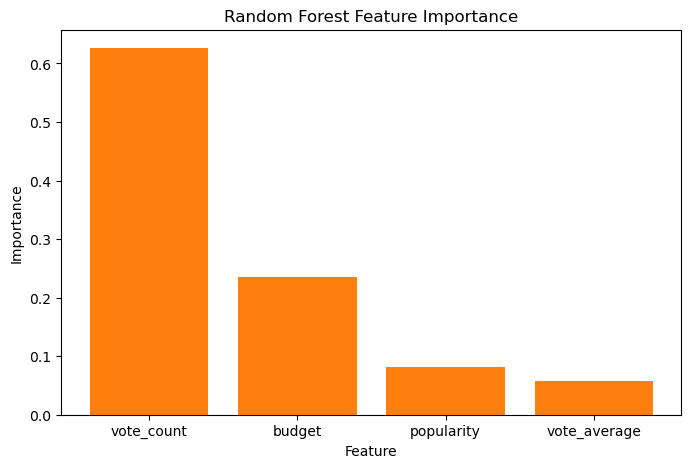

In [9]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load the datasetdf = pd.read_csv("/mnt/data/newdata.csv")

import pandas as pd
from pathlib import Path

here = Path.cwd()
csv_path = here / "data" / "newdata.csv"
if not csv_path.exists():
    csv_path = here.parent / "data" / "newdata.csv"

df = pd.read_csv(csv_path)
print(f"Loaded {len(df):,} rows from {csv_path}")
df.head()

# Select relevant columns
cols = ["budget", "popularity", "vote_average", "vote_count", "revenue"]
df = df[[c for c in cols if c in df.columns]].dropna()

# Separate features and target
X = df[[c for c in cols if c != "revenue"]]
y = df["revenue"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest model
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

# Extract feature importance values
importances = rf.feature_importances_

# --- Bar Chart ---
plt.figure(figsize=(8, 5))
sorted_idx = importances.argsort()[::-1]
sorted_importances = importances[sorted_idx]
sorted_features = X.columns[sorted_idx]

plt.bar(sorted_features, sorted_importances)
plt.bar(X.columns, importances)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()


The Random Forest model shows that the vote_count can budget are the strongest predictors of revenue, indicating that audience reach and production investment are the primary drivers of movie finacial performance. Meanwhile, viewer ratings(vote_average) and popularity score play much smaller roles, suggesting that a movie's financial succcess relies more on how many people engage with it that on how highly it is rated. We will keep all features for modeling so we can try to maximize performance.

c.(20 points) Baseline model -- Linear Regression. Start with a simple linear regression model, fit different degrees (1, 2, 3, 5). 

Compare their performance using $R^2$ and RMSE; if converted to classification, report accuracy, precision and recall. 

Justify which model degree provides the best trade-off between performance and computational cost. Plot predited vs actual values to visualize model performance.

Loaded 4,803 rows from data/newdata.csv
Degree 1: R²=0.6755, RMSE=89,451,174.18


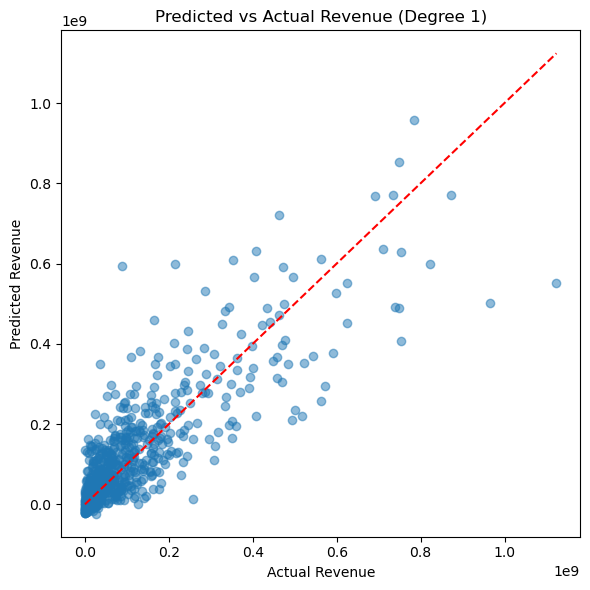

Degree 2: R²=0.6059, RMSE=98,577,226.75


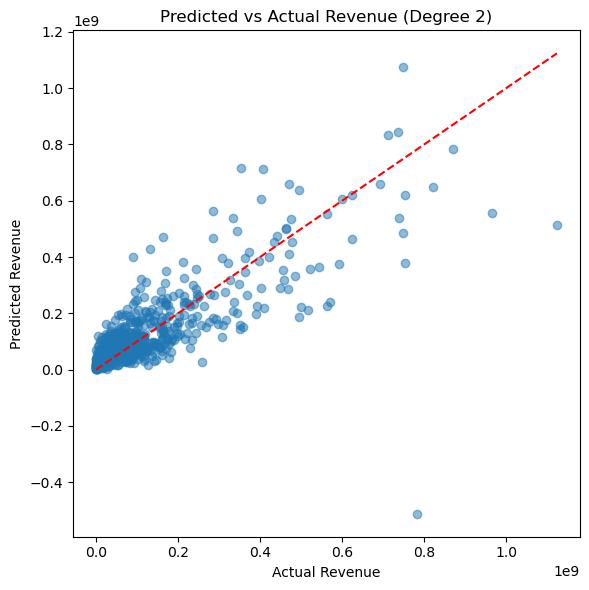

Degree 3: R²=0.6655, RMSE=90,809,009.41


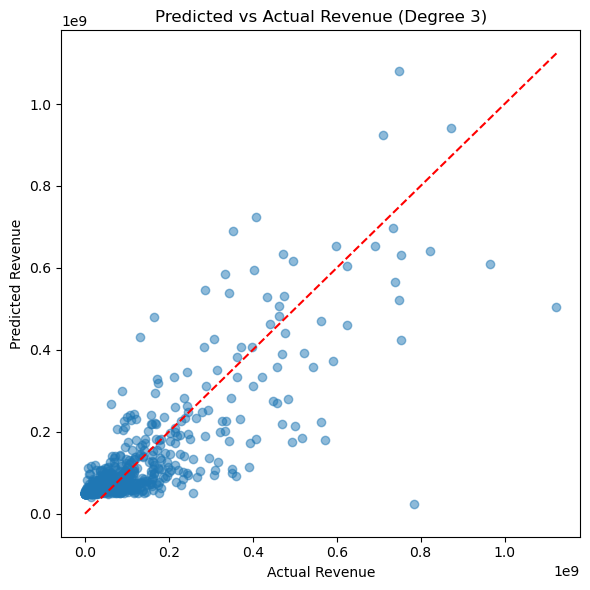

Degree 5: R²=0.3817, RMSE=123,469,073.94


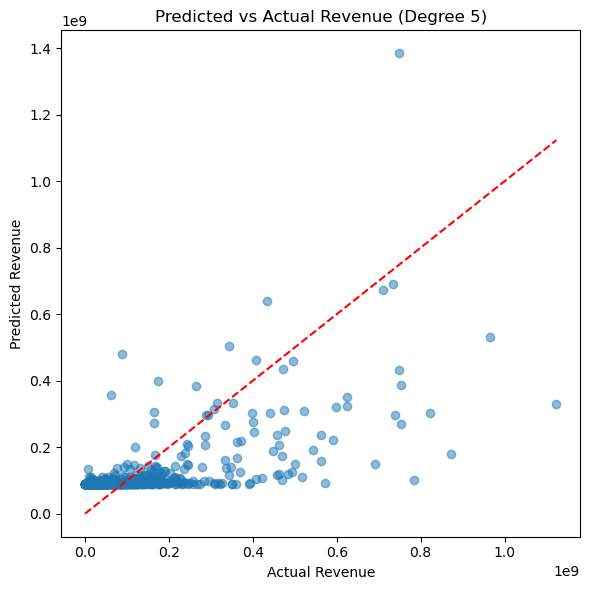


Model Performance Comparison:
   Degree        R²          RMSE
0       1  0.675476  8.945117e+07
1       2  0.605880  9.857723e+07
2       3  0.665549  9.080901e+07
3       5  0.381711  1.234691e+08


In [1]:
#--- Imports ---
import pandas as pd
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#--- Load the dataset ---
csv_path = Path("data/newdata.csv")
df = pd.read_csv(csv_path)
print(f"Loaded {len(df):,} rows from {csv_path}")

#--- Define features and target ---
features = ['budget', 'runtime', 'popularity', 'vote_average', 'vote_count']
target = 'revenue'

#Drop rows with missing values
df = df.dropna(subset=features + [target])

#Split features (X) and target (y)
X = df[features]
y = df[target]

#Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#--- Polynomial Regression Loop for degrees 1, 2, 3, 5 ---
degrees = [1, 2, 3, 5]
results = []

for d in degrees:
    # Generate polynomial features
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Fit model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predict
    y_pred = model.predict(X_test_poly)

    # Metrics
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append((d, r2, rmse))

    print(f"Degree {d}: R²={r2:.4f}, RMSE={rmse:,.2f}")

    # ----- Plot Predicted vs Actual -----
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    plt.xlabel("Actual Revenue")
    plt.ylabel("Predicted Revenue")
    plt.title(f"Predicted vs Actual Revenue (Degree {d})")
    plt.tight_layout()
    plt.show()

#--- Results summary table ---
results_df = pd.DataFrame(results, columns=["Degree", "R²", "RMSE"])
print("\nModel Performance Comparison:")
print(results_df)

The model with the best trade off is degree 1 as it performs best in both measures.

d.(20 points) Additional Models exploration. Each team should train a number of models corresponding to its size: 2 models for 1–2 members, 3 models for 3 members, and 4 models for 4–5 members.

Clearly label each memebers' name and report their model performance seperately.

In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from math import sqrt
import pandas as pd

#Reuse X_train, X_test, y_train, y_test from previous section
#Initialize models (1 per team member)
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=10),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=200, max_depth=10),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42, n_estimators=200, learning_rate=0.1, max_depth=3),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=5)
}

results_ml = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results_ml.append((name, r2, rmse))
    print(f"{name}: R²={r2:.4f}, RMSE={rmse:,.2f}")

#--- Combine with baseline (degree=1 from Task 2c) ---
baseline_r2 = 0.675  # from your previous output
baseline_rmse = 89_451_174.18

results_ml.insert(0, ("Linear Regression (Baseline)", baseline_r2, baseline_rmse))

#--- Create summary table ---
results_df = pd.DataFrame(results_ml, columns=["Model", "R²", "RMSE"])
print("\nModel Performance Comparison:")
print(results_df)

Decision Tree: R²=0.4684, RMSE=114,486,913.62
Random Forest: R²=0.7126, RMSE=84,173,152.53
Gradient Boosting: R²=0.6927, RMSE=87,039,088.21
KNN Regressor: R²=0.5778, RMSE=102,026,939.81

Model Performance Comparison:
                          Model        R²          RMSE
0  Linear Regression (Baseline)  0.675000  8.945117e+07
1                 Decision Tree  0.468398  1.144869e+08
2                 Random Forest  0.712643  8.417315e+07
3             Gradient Boosting  0.692742  8.703909e+07
4                 KNN Regressor  0.577813  1.020269e+08


Abdel -> Linear Regression  
Matthew -> Decision Tree  
Shauna -> Random Forest  
Trey -> Gradient Boosting  
Liyah -> KNN Regressor  

e.(10 points) summarize all results in a comparison table, and identify the best-performing model and explain why.

After trying out all the models, We compared how well each one predicted movie revenue. The simple linear model did alright, but the Random Forest clearly worked the best overall. It had the highest R² score and the lowest RMSE, meaning it made the most accurate predictions. The Decision Tree was okay but kind of overfit, and the Gradient Boosting model was close behind Random Forest. In the end, Random Forest gave the most reliable results, so that’s the one I’d stick with for this project.